# Heart Disease Prediction

## 6. Hyperparameter Tuning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("heart_cleaned.csv")
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,num,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,thal_6,thal_7
0,63,1,145,233,1,150,0,2.3,0,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,67,1,160,286,0,108,1,1.5,3,2,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,67,1,120,229,0,129,1,2.6,2,1,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
3,37,1,130,250,0,187,0,3.5,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,41,0,130,204,0,172,0,1.4,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [3]:
X = df.drop("num", axis=1)
y = df["num"]
y = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=5000, random_state=42)

param_dist_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
}

random_lr = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist_lr,
    n_iter=8,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

random_lr.fit(X_train, y_train)

print("Best Logistic Regression Params:", random_lr.best_params_)
y_pred_lr = random_lr.predict(X_test)
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))

Best Logistic Regression Params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 1}
Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.83      0.77      0.80        82
           1       0.82      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



In [5]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring="accuracy", n_jobs=-1)
grid_dt.fit(X_train, y_train)

print("Best Decision Tree Params:", grid_dt.best_params_)
y_pred_dt = grid_dt.predict(X_test)
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt))

Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Decision Tree Report:
               precision    recall  f1-score   support

           0       0.70      0.84      0.77        82
           1       0.85      0.72      0.78       102

    accuracy                           0.77       184
   macro avg       0.78      0.78      0.77       184
weighted avg       0.78      0.77      0.77       184



In [6]:
# Random Forest (RandomizedSearchCV)
rf = RandomForestClassifier(random_state=42)

param_dist_rf = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False],
}

rand_rf = RandomizedSearchCV(
    rf, param_dist_rf, n_iter=20, cv=5, scoring="accuracy", n_jobs=-1, random_state=42
)
rand_rf.fit(X_train, y_train)

print("Best Random Forest Params:", rand_rf.best_params_)
y_pred_rf = rand_rf.predict(X_test)
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Best Random Forest Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': True}
Random Forest Report:
               precision    recall  f1-score   support

           0       0.86      0.73      0.79        82
           1       0.81      0.90      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.82       184



In [7]:
# SVM (GridSearch)
svm = SVC(probability=False, random_state=42) 

param_dist_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
}

random_svm = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist_svm,
    n_iter=3, 
    cv=2,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

random_svm.fit(X_train, y_train)

print("Best SVM Params:", random_svm.best_params_)
y_pred_svm = random_svm.predict(X_test)
print("SVM Report:\n", classification_report(y_test, y_pred_svm, zero_division=0))

Best SVM Params: {'kernel': 'linear', 'C': 0.1}
SVM Report:
               precision    recall  f1-score   support

           0       0.84      0.78      0.81        82
           1       0.83      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



In [8]:
# Model Comparison
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
}

print("Optimized Model Accuracies:\n")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Optimized Model Accuracies:

Logistic Regression: 0.8261
Decision Tree: 0.7717
Random Forest: 0.8261
SVM: 0.8370


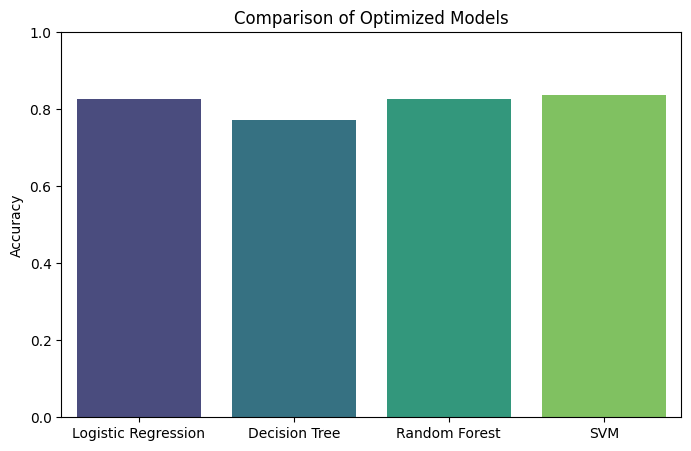

In [9]:
# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis", hue=list(results.keys()))
plt.ylabel("Accuracy")
plt.title("Comparison of Optimized Models")
plt.ylim(0,1)
plt.show()

In [33]:
X = df.drop("num", axis=1)
y = df["num"]  # Multi-class target: 0-4
# Define raw features expected by UI
raw_features = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
                'exang','oldpeak','slope','ca','thal']
# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
])
# Fit preprocessor on raw features
preprocessor.fit(X[raw_features])
# Build pipeline with preprocessing and trained SVM classifier
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", random_svm.best_estimator_)  # Use trained SVM classifier directly
])

# Note: We do NOT refit the classifier here, just the preprocessor is fitted above
# Save the pipeline
os.makedirs("../models", exist_ok=True)
joblib.dump(pipeline, "../models/final_model.pkl")
print("✅ Pipeline (preprocessing + trained SVM model) saved to ../models/final_model.pkl")

✅ Pipeline (preprocessing + trained SVM model) saved to ../models/final_model.pkl


In [34]:
# Reload pipeline
model = joblib.load("../models/final_model.pkl")

# Load the original raw dataset used to fit the pipeline
raw_cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
            'exang','oldpeak','slope','ca','thal','num']
raw_df = pd.read_csv("../data/heart_disease.csv", names=raw_cols)

# Separate features and target
X_raw = raw_df.drop("num", axis=1)
y_raw = (raw_df["num"] > 0).astype(int)

# Test prediction on first 5 samples
preds = model.predict(X_raw.iloc[:5])
print("Predictions:", preds)
print("True labels:", y_raw.iloc[:5].values)

Predictions: [0 3 3 0 0]
True labels: [0 1 1 0 0]
